# Secondary school student performance: EDA and baseline model

**Dataset:** UCI *Student Performance* (Cortez & Silva, 2008). It covers students from two Portuguese secondary schools, Gabriel Pereira (`GP`) and Mousinho da Silveira (`MS`), collected in 2005/06.

**Main question:** which factors are associated with the final grade (`G3`, 0–20 scale), and how well can we predict it?

**Outline**
1. Load and understand the data
2. Data quality
3. The target variable (`G3`)
4. Exploration: which factors relate to the grade?
5. Modelling: baseline and two scenarios (with and without mid-year grades)
6. Which features matter most?
7. Conclusions and next steps

> If you don't have the data yet, run `python src/download_data.py` from the project folder first.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (8, 4.5)
pd.set_option("display.max_columns", 40)

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW = ROOT / "data" / "raw"
FIG = ROOT / "figures"
FIG.mkdir(exist_ok=True)

def save_fig(name):
    plt.tight_layout()
    plt.savefig(FIG / f"{name}.png", dpi=120)

## 1. Load and understand the data

There are two files: Portuguese language (`student-por.csv`, 649 students) and Maths (`student-mat.csv`, 395 students). Both use `;` as the separator.
We work with **Portuguese** because it has more students. Repeating the analysis for Maths is a good exercise.

In [2]:
por = pd.read_csv(RAW / "student-por.csv", sep=";")
mat = pd.read_csv(RAW / "student-mat.csv", sep=";")
df = por.copy()
print("Portuguese:", por.shape, "| Maths:", mat.shape)
df.head()

Portuguese: (649, 33) | Maths: (395, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,0,yes,no,no,no,yes,yes,yes,no,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,no,yes,yes,yes,yes,yes,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,no,no,yes,yes,no,no,4,3,2,1,2,5,0,11,13,13


### Data dictionary (summary)

| Group | Variables |
|---|---|
| Demographics | `school`, `sex`, `age`, `address` (U = urban, R = rural) |
| Family | `famsize`, `Pstatus` (parents together/apart), `Medu`/`Fedu` (mother's/father's education, 0–4), `Mjob`/`Fjob`, `guardian`, `famrel` (quality of family relationships, 1–5) |
| School | `reason` (why this school), `traveltime`, `studytime` (1–4), `failures` (past class failures), `schoolsup` (extra educational support), `famsup`, `paid` (paid tutoring), `absences` |
| Lifestyle | `activities`, `nursery`, `higher` (wants higher education), `internet`, `romantic`, `freetime`, `goout`, `Dalc`/`Walc` (weekday/weekend alcohol use, 1–5), `health` |
| Grades | `G1` (1st term), `G2` (2nd term), `G3` (**final grade, the target**) |

Full description in `data/raw/student.txt`.

## 2. Data quality

In [3]:
print("Missing values:", df.isna().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print()
print(df.dtypes.value_counts())

Missing values: 0
Duplicate rows: 0

object    17
int64     16
Name: count, dtype: int64


In [4]:
num_cols = df.select_dtypes("number").columns.tolist()
cat_cols = df.select_dtypes("object").columns.tolist()
print("Numeric:", num_cols)
print("Categorical:", cat_cols)
df[num_cols].describe().T

Numeric: ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']
Categorical: ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']


,count,mean,std,min,25%,50%,75%,max
age,649.0,16.744222,1.218138,15.0,16.0,17.0,18.0,22.0
Medu,649.0,2.514638,1.134552,0.0,2.0,2.0,4.0,4.0
Fedu,649.0,2.306626,1.099931,0.0,1.0,2.0,3.0,4.0
traveltime,649.0,1.568567,0.748660,1.0,1.0,1.0,2.0,4.0
studytime,649.0,1.930663,0.829510,1.0,1.0,2.0,2.0,4.0
failures,649.0,0.221880,0.593235,0.0,0.0,0.0,0.0,3.0
famrel,649.0,3.930663,0.955717,1.0,4.0,4.0,5.0,5.0
freetime,649.0,3.180277,1.051093,1.0,3.0,3.0,4.0,5.0
goout,649.0,3.184900,1.175766,1.0,2.0,3.0,4.0,5.0
Dalc,649.0,1.502311,0.924834,1.0,1.0,1.0,2.0,5.0


No missing values or duplicates, which is rare with real-world data (this dataset comes pre-cleaned).
Two things still need attention:
- Many "numeric" variables are actually **ordinal** (1–5 scales, for example). Treating them as numbers is an acceptable simplification for a first model.
- `absences` has a long tail (see the maximum).

## 3. The target variable: `G3`

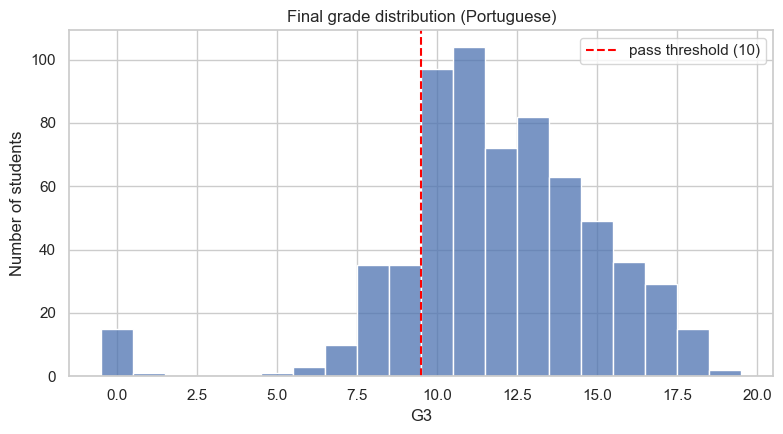

Students with G3 = 0: 15 (2.3%)
Pass rate (G3 >= 10): 84.6%


In [5]:
fig, ax = plt.subplots()
sns.histplot(df["G3"], bins=range(0, 21), discrete=True, ax=ax)
ax.axvline(9.5, color="red", ls="--", label="pass threshold (10)")
ax.set(title="Final grade distribution (Portuguese)", xlabel="G3", ylabel="Number of students")
ax.legend()
save_fig("01_G3_distribution")
plt.show()

zeros = (df["G3"] == 0).sum()
print(f"Students with G3 = 0: {zeros} ({zeros / len(df):.1%})")
print(f"Pass rate (G3 >= 10): {(df['G3'] >= 10).mean():.1%}")

**First finding:** there is a group of students with a **final grade of 0**, separated from the rest of the distribution.
A 0 out of 20 is unlikely to be a "real" grade. These are more likely students who dropped out or were not assessed.
Let's take a closer look:

In [6]:
df.assign(G3_zero=df["G3"] == 0).groupby("G3_zero")[["G1", "G2", "absences", "failures"]].mean().round(2)

,G1,G2,absences,failures
G3_zero,,,,
False,11.50,11.75,3.75,0.21
True,7.07,3.80,0.00,0.80


The 15 students with `G3 = 0` **did get a 1st-term grade** (`G1` between 4 and 11), but their 2nd-term grades collapse (mean `G2` ≈ 3.8, many at 0). They also have more past failures and, interestingly, every one of them has **zero recorded absences**.
This fits the dropout hypothesis: a student who left school mid-year stops accumulating recorded absences.

Decision: we keep them for now. A more complete project could treat them as a separate problem (dropout prediction).

## 4. Exploration: which factors relate to the grade?

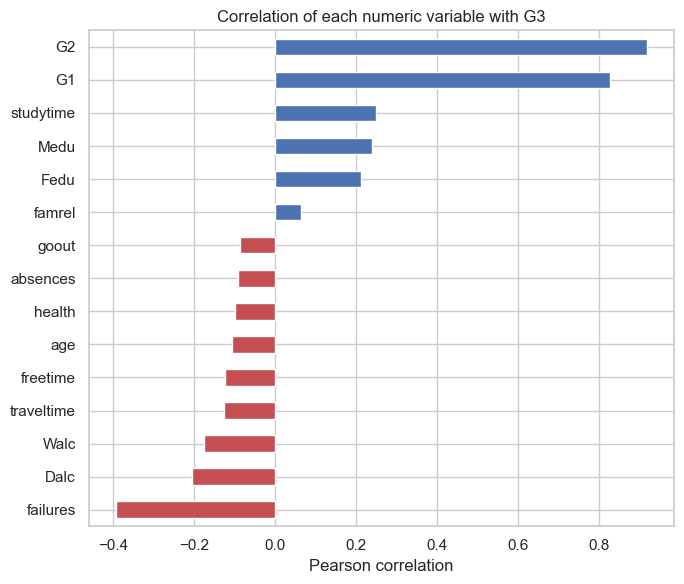

In [7]:
corr = df[num_cols].corr()["G3"].drop("G3").sort_values()
fig, ax = plt.subplots(figsize=(7, 6))
corr.plot.barh(ax=ax, color=np.where(corr > 0, "#4c72b0", "#c44e52"))
ax.set(title="Correlation of each numeric variable with G3", xlabel="Pearson correlation")
save_fig("02_G3_correlations")
plt.show()

Unsurprisingly, `G1` and `G2` correlate almost perfectly with `G3`: students who do well in the first terms do well at the end.
Setting them aside, the strongest factor by far is the **number of past failures** (`failures`, r ≈ −0.39).
Next come study time (+0.25), mother's education (+0.24), father's education (+0.21) and weekday alcohol use (−0.21).
All of these are weak to moderate correlations.

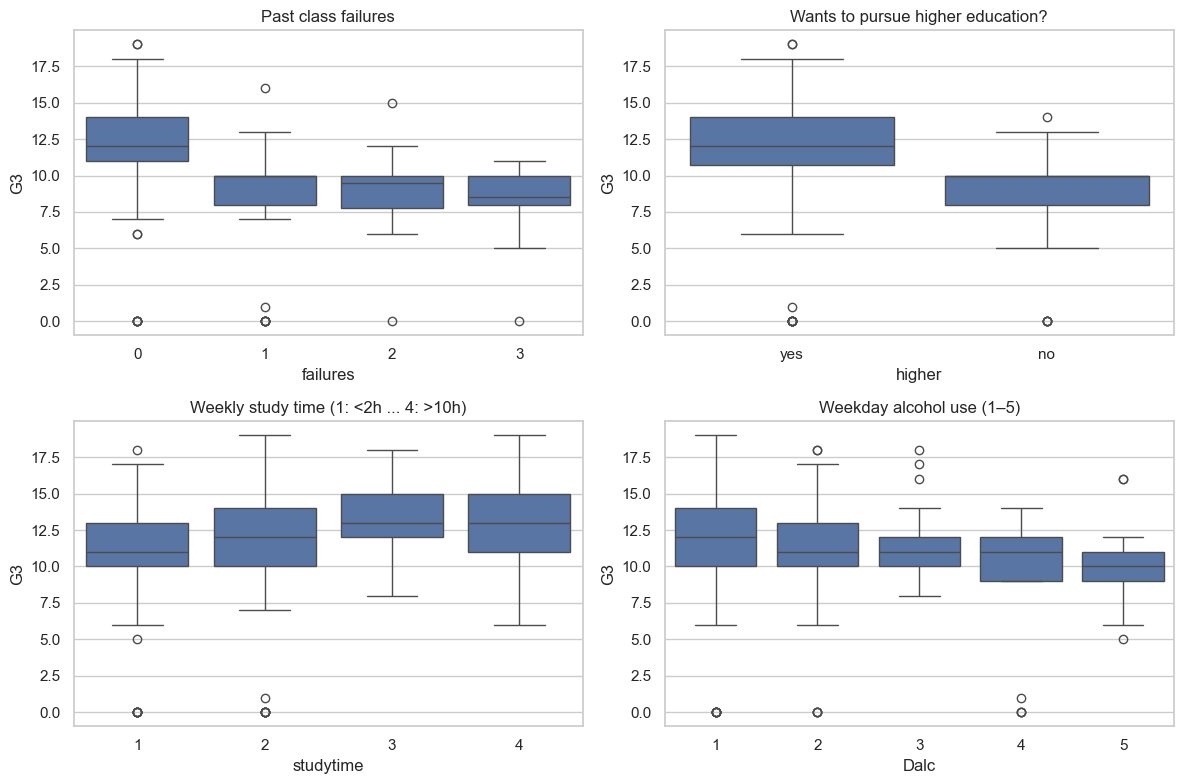

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.boxplot(data=df, x="failures", y="G3", ax=axes[0, 0])
axes[0, 0].set_title("Past class failures")

sns.boxplot(data=df, x="higher", y="G3", ax=axes[0, 1])
axes[0, 1].set_title("Wants to pursue higher education?")

sns.boxplot(data=df, x="studytime", y="G3", ax=axes[1, 0])
axes[1, 0].set_title("Weekly study time (1: <2h ... 4: >10h)")

sns.boxplot(data=df, x="Dalc", y="G3", ax=axes[1, 1])
axes[1, 1].set_title("Weekday alcohol use (1–5)")

save_fig("03_main_factors")
plt.show()

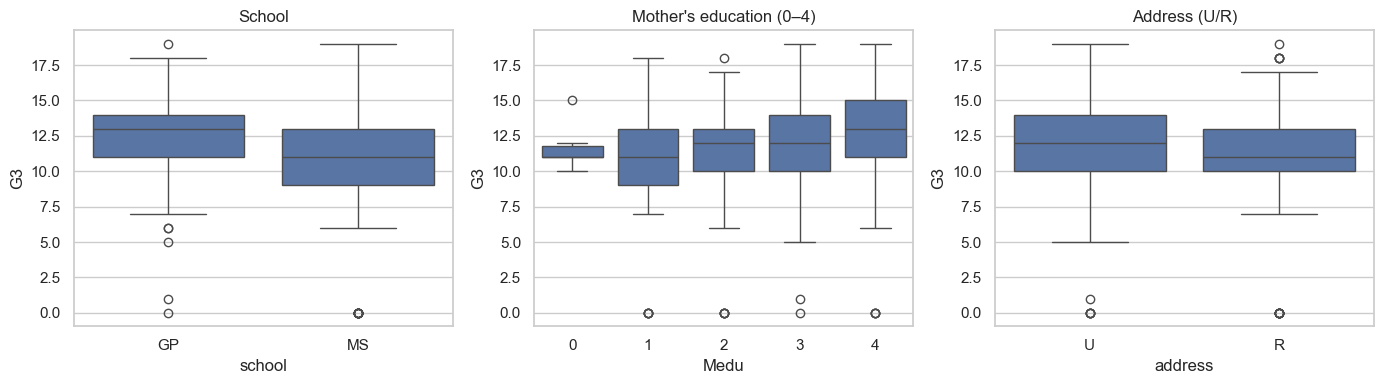

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col, title in zip(axes, ["school", "Medu", "address"],
                          ["School", "Mother's education (0–4)", "Address (U/R)"]):
    sns.boxplot(data=df, x=col, y="G3", ax=ax)
    ax.set_title(title)
save_fig("04_context")
plt.show()

In [10]:
# Group means quantify what the plots show
for col in ["failures", "higher", "school", "schoolsup"]:
    print(df.groupby(col)["G3"].agg(["mean", "count"]).round(2), "\n")

           mean  count
failures              
0         12.51    549
1          8.64     70
2          8.81     16
3          8.07     14 

         mean  count
higher              
no       8.80     69
yes     12.28    580 

         mean  count
school              
GP      12.58    423
MS      10.65    226 

            mean  count
schoolsup              
no         11.98    581
yes        11.28     68 



**Exploration summary**
- **Past failures** are the strongest signal: the mean grade drops from 12.5 to around 8.5 after just one failure.
- **Wanting to go to university** (`higher`) is linked to much higher grades (12.3 vs 8.8). It acts as a motivation proxy.
- **School:** GP outperforms MS (12.6 vs 10.7). This may reflect socio-economic context rather than school quality.
- **Mother's education**, **study time** and **alcohol** have visible but more moderate effects.
- `schoolsup` (extra educational support) is associated with *lower* grades. This is a textbook case of **reverse causation**: support is given to students who are already struggling.

⚠️ These are **associations**, not causes.

## 5. Modelling

### Watch out for data leakage
`G1` and `G2` explain almost everything, but they are only known mid-year. Whether to use them depends on the question:
- **Scenario A, early warning** (no `G1`/`G2`): at the start of the year, using only background data, can we identify students at risk?
- **Scenario B, mid-year** (with `G1`/`G2`): after the 2nd term, how well can we predict the final grade?

Scenario A is the more interesting one, and the more honest framing for a project.

### Metrics
- **MAE** (mean absolute error): "on average, we're off by X points".
- **RMSE**: penalises large errors more heavily.
- **R²**: share of variance explained.

We use **5-fold cross-validation** to get stable estimates on a small dataset.

In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

y = df["G3"]
X_A = df.drop(columns=["G1", "G2", "G3"])  # scenario A: early warning
X_B = df.drop(columns=["G3"])              # scenario B: with mid-year grades

def preprocessor(X):
    num = X.select_dtypes("number").columns
    cat = X.select_dtypes("object").columns
    return ColumnTransformer([
        ("num", StandardScaler(), num),
        ("cat", OneHotEncoder(drop="if_binary", handle_unknown="ignore"), cat),
    ])

def models(X):
    return {
        "Baseline (mean)": DummyRegressor(strategy="mean"),
        "Ridge (linear)": Pipeline([("prep", preprocessor(X)), ("model", RidgeCV(alphas=np.logspace(-2, 3, 20)))]),
        "Random Forest": Pipeline([("prep", preprocessor(X)),
                                   ("model", RandomForestRegressor(n_estimators=300, min_samples_leaf=3, random_state=42, n_jobs=-1))]),
    }

cv = KFold(n_splits=5, shuffle=True, random_state=42)
scoring = {"MAE": "neg_mean_absolute_error", "RMSE": "neg_root_mean_squared_error", "R2": "r2"}

results = []
for scenario, X in [("A: no G1/G2", X_A), ("B: with G1/G2", X_B)]:
    for name, model in models(X).items():
        s = cross_validate(model, X, y, cv=cv, scoring=scoring)
        results.append({
            "Scenario": scenario, "Model": name,
            "MAE": -s["test_MAE"].mean(), "RMSE": -s["test_RMSE"].mean(), "R²": s["test_R2"].mean(),
        })

res = pd.DataFrame(results).round(2)
res

,Scenario,Model,MAE,RMSE,R²
0,A: no G1/G2,Baseline (mean),2.41,3.21,-0.01
1,A: no G1/G2,Ridge (linear),1.98,2.73,0.26
2,A: no G1/G2,Random Forest,1.99,2.68,0.29
3,B: with G1/G2,Baseline (mean),2.41,3.21,-0.01
4,B: with G1/G2,Ridge (linear),0.83,1.28,0.84
5,B: with G1/G2,Random Forest,0.80,1.23,0.85


**Reading the results**
- The **baseline** (always predict the mean) is the minimum bar. Any model must beat it.
- **Scenario A:** the models beat the baseline (MAE ≈ 2.0 vs 2.4 points), but R² stays around 0.26–0.29. Background factors explain only part of the grade, which is realistic: much depends on what happens during the year.
- **Scenario B:** with `G1`/`G2` the error drops to ~0.8 points (R² ≈ 0.85). Predicting the final grade once the 2nd-term grade is known is "easy", but too late to intervene.
- Ridge and Random Forest perform almost identically. When a simple, interpretable model ties with a complex one, the simple one is usually preferred.

## 6. Which features matter most? (Scenario A)

We use *permutation importance*: shuffle one feature at a time and measure how much the model gets worse.
It is computed on a held-out test set to avoid bias.

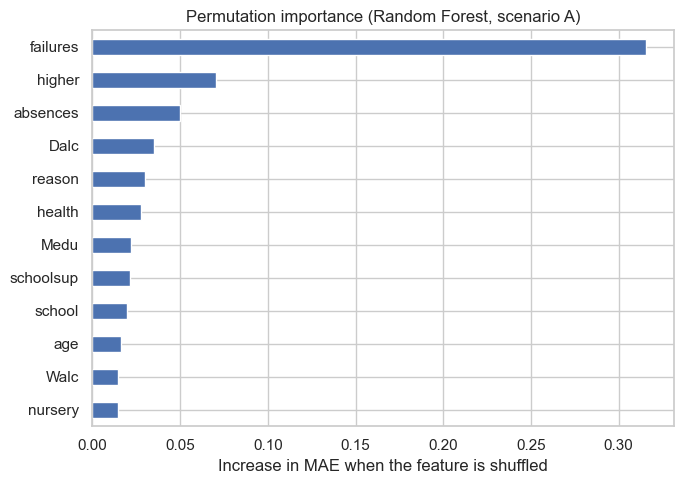

In [12]:
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

X_tr, X_te, y_tr, y_te = train_test_split(X_A, y, test_size=0.25, random_state=42)
rf = models(X_A)["Random Forest"].fit(X_tr, y_tr)

pi = permutation_importance(rf, X_te, y_te, n_repeats=20, random_state=42,
                            scoring="neg_mean_absolute_error", n_jobs=-1)
imp = pd.Series(pi.importances_mean, index=X_A.columns).sort_values().tail(12)

fig, ax = plt.subplots(figsize=(7, 5))
imp.plot.barh(ax=ax)
ax.set(title="Permutation importance (Random Forest, scenario A)",
       xlabel="Increase in MAE when the feature is shuffled")
save_fig("05_feature_importance")
plt.show()

- `failures` dominates, which confirms the exploration.
- Next come `higher` (motivation), `absences` and `Dalc`.
- **Interesting:** `absences` has a weak linear correlation with `G3` (−0.09), yet the Random Forest finds it important. Why? Because the relationship is **non-linear**: students with zero absences include the dropout cases (grade 0). A tree-based model picks this up; Pearson correlation does not.

## 7. Conclusions

1. The data is clean, but there is a **group of zero grades** that most likely reflects dropout and deserves its own analysis.
2. **Past failures** are by far the background factor most associated with the final grade. They are followed by **intention to pursue higher education**, **absences** (in a non-linear way) and **alcohol use**.
3. Without mid-year grades, the models **beat the baseline** but explain only part of the variance. With them, prediction becomes almost trivial.
4. For a school, the real value lies in **scenario A**: an early-warning system that flags at-risk students at the start of the year.

## Next steps (exercises)

- [ ] **Classification:** turn the target into `passed = G3 >= 10` and train a classifier. Evaluate with recall and precision: in an early-warning system, missing an at-risk student costs more than a false alarm.
- [ ] **Zero grades:** remove them, or model them separately, and see how the results change.
- [ ] **Maths:** repeat everything with `student-mat.csv` (it is harder and has more failures).
- [ ] **Merge both subjects:** the authors note 382 students appear in both files (matched on demographic attributes). This lets you compare Portuguese and Maths for the same student.
- [ ] **Better model:** try Gradient Boosting (`HistGradientBoostingRegressor`), tune hyperparameters with `GridSearchCV` and interpret with SHAP.
- [ ] **Communicate:** turn the findings into a Streamlit dashboard or a 5-slide presentation. This is what sets a portfolio apart.